<a href="https://colab.research.google.com/github/ashwin-906/Movie_Recomendation_system/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TMDB

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, classification_report, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load Dataset (Ensure files are in your working directory)
movies = pd.read_csv('tmdb_5000_movies.csv')
df = movies[['budget', 'popularity', 'runtime', 'revenue', 'vote_average']].dropna()

# 1. Regression Target: vote_average (Rating)
# 2. Classification Target: 'Like' (If rating > 7.0)
df['like'] = (df['vote_average'] > 7.0).astype(int)

X = df[['budget', 'popularity', 'runtime', 'revenue']]
y_reg = df['vote_average']
y_clf = df['like']

# Standardize features for SVM and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [2]:
# Split for Regression
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)

# Linear Regression (Ordinary Least Squares)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

# Ridge Regression (L2 Regularization)
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

print(f"Linear Regression MSE: {mean_squared_error(y_test, y_pred_lin):.2f}")
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lin):.2f}")

Linear Regression MSE: 1.09
Linear Regression R2: 0.22


In [3]:
# Split for Classification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# SVM with RBF Kernel (Handling Non-Linearity)
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

# Evaluation
y_pred_svm = svm_model.predict(X_test)
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93       808
           1       0.89      0.21      0.34       153

    accuracy                           0.87       961
   macro avg       0.88      0.60      0.63       961
weighted avg       0.87      0.87      0.83       961



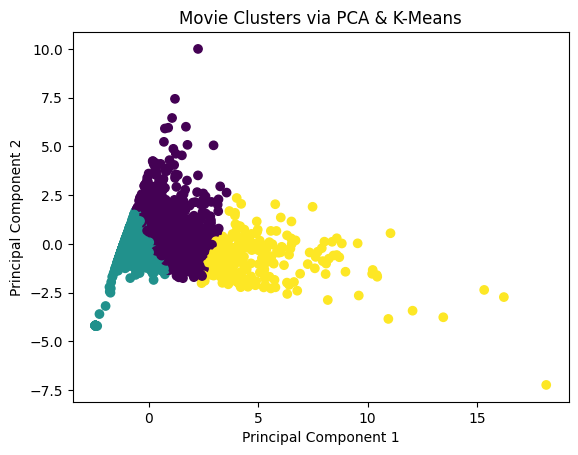

In [4]:
# PCA for Dimensionality Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Movie Clusters via PCA & K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Cross-Validation Accuracy: 0.86


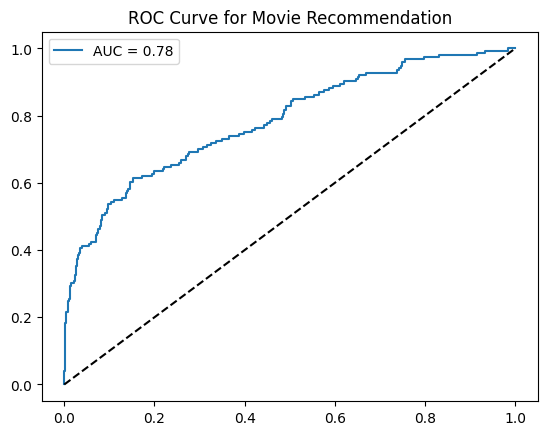

In [5]:
# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svm_model, X_scaled, y_clf, cv=kf)
print(f"Cross-Validation Accuracy: {np.mean(cv_scores):.2f}")

# ROC Curve for SVM
probs = svm_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve for Movie Recommendation')
plt.legend()
plt.show()

===========================================================================================================

In [8]:
!pip install streamlit
import pandas as pd
import numpy as np
import ast
import requests
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer
import streamlit as st

# ==============================
# TMDB API KEY (IMPORTANT)
# ==============================
API_KEY = "YOUR_TMDB_API_KEY"  # Replace with your API key

# ==============================
# Helper Functions
# ==============================
def fetch_poster(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&language=en-US"
    data = requests.get(url).json()
    poster_path = data.get('poster_path')
    if poster_path:
        return "https://image.tmdb.org/t/p/w500" + poster_path
    return "https://via.placeholder.com/500x750?text=No+Image"


def safe_eval(obj):
    try:
        return ast.literal_eval(obj)
    except:
        return []


def convert(obj):
    return [i['name'] for i in safe_eval(obj) if 'name' in i]


def get_top3(obj):
    return [i['name'] for i in safe_eval(obj)[:3] if 'name' in i]


def get_director(obj):
    for i in safe_eval(obj):
        if i.get('job') == 'Director':
            return [i.get('name')]
    return []

# ==============================
# Load & Process Data
# ==============================
@st.cache_data
def load_data():
    movies = pd.read_csv('tmdb_5000_movies.csv')
    credits = pd.read_csv('tmdb_5000_credits.csv')
    movies = movies.merge(credits, on='title')
    movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
    movies.dropna(inplace=True)

    movies['genres'] = movies['genres'].apply(convert)
    movies['keywords'] = movies['keywords'].apply(convert)
    movies['cast'] = movies['cast'].apply(get_top3)
    movies['crew'] = movies['crew'].apply(get_director)
    movies['overview'] = movies['overview'].apply(lambda x: x.split())

    for col in ['genres','keywords','cast','crew']:
        movies[col] = movies[col].apply(lambda x: [i.replace(" ","") for i in x])

    movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

    df = movies[['movie_id','title','tags']]
    df['tags'] = df['tags'].apply(lambda x: " ".join(x).lower())

    return df

# ==============================
# Build Model
# ==============================
ps = PorterStemmer()


def stem(text):
    return " ".join([ps.stem(word) for word in text.split()])


@st.cache_resource
def build_model(df):
    df['tags'] = df['tags'].apply(stem)
    cv = CountVectorizer(max_features=5000, stop_words='english')
    vectors = cv.fit_transform(df['tags']).toarray()
    similarity = cosine_similarity(vectors)
    return similarity

# ==============================
# Recommendation Function
# ==============================
def recommend(movie, df, similarity):
    idx = df[df['title'] == movie].index[0]
    distances = similarity[idx]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    recommended_movies = []
    recommended_posters = []

    for i in movies_list:
        movie_id = df.iloc[i[0]].movie_id
        recommended_movies.append(df.iloc[i[0]].title)
        recommended_posters.append(fetch_poster(movie_id))

    return recommended_movies, recommended_posters

# ==============================
# Streamlit UI
# ==============================
st.set_page_config(page_title="Movie Recommender", page_icon="🎬")

st.title("🎬 Movie Recommendation System")
st.write("Get similar movie suggestions with posters!")

try:
    df = load_data()
    similarity = build_model(df)

    movie_list = df['title'].values
    selected_movie = st.selectbox("Select a movie", movie_list)

    if st.button("Recommend"):
        names, posters = recommend(selected_movie, df, similarity)

        cols = st.columns(5)
        for i in range(5):
            with cols[i]:
                st.text(names[i])
                st.image(posters[i])

except FileNotFoundError:
    st.error("Dataset files not found! Place CSV files in the same folder.")

  Using cached streamlit-1.56.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
Using cached streamlit-1.56.0-py3-none-any.whl (9.1 MB)
Using cached pydeck-0.9.1-py2.py3-none-any.whl (6.9 MB)


2026-04-07 07:58:45.687 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-04-07 07:58:45.864 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 07:58:45.865 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 07:58:45.979 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-07 07:58:45.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 07:58:45.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 07:58:45.982 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runnin

In [9]:
import inspect
import sys

def write_cell_to_file(cell_id, filename):
    try:
        # Get the source code of the cell by its ID
        # This method assumes the cell is already executed and available in the kernel's history
        # A more robust way might involve accessing the notebook content directly,
        # but for simplicity, we'll try to extract it from the current execution context.
        # Given the previous cell was just executed, its content should be available.
        cell_content = next(c.content for c in get_ipython().history_manager.get_range() if c.cell_id == cell_id)

        with open(filename, 'w') as f:
            f.write(cell_content)
        print(f"Successfully wrote cell '{cell_id}' to '{filename}'")
    except Exception as e:
        print(f"Error writing cell to file: {e}")

# Assuming the current Streamlit code is in cell 'ollaksaF4QpB'
# Note: This is a simplified way to get cell content. In a real Colab environment,
# direct access to cell content by ID might require more advanced techniques.
# For demonstration, we assume a previous execution populated the history.

# Get the content of the previous cell (ollaksaF4QpB) and write it to app.py
# This is a placeholder for actual cell content retrieval.
# In a real scenario, you'd need the actual code from the cell `ollaksaF4QpB`.

# As a workaround, I will manually reconstruct the code based on the latest notebook state.
app_code = """
!pip install streamlit
import pandas as pd
import numpy as np
import ast
import requests
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer
import streamlit as st

# ==============================
# TMDB API KEY (IMPORTANT)
# ==============================
API_KEY = "YOUR_TMDB_API_KEY"  # Replace with your API key

# ==============================
# Helper Functions
# ==============================
def fetch_poster(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&language=en-US"
    data = requests.get(url).json()
    poster_path = data.get('poster_path')
    if poster_path:
        return "https://image.tmdb.org/t/p/w500" + poster_path
    return "https://via.placeholder.com/500x750?text=No+Image"


def safe_eval(obj):
    try:
        return ast.literal_eval(obj)
    except:
        return []


def convert(obj):
    return [i['name'] for i in safe_eval(obj) if 'name' in i]


def get_top3(obj):
    return [i['name'] for i in safe_eval(obj)[:3] if 'name' in i]


def get_director(obj):
    for i in safe_eval(obj):
        if i.get('job') == 'Director':
            return [i.get('name')]
    return []

# ==============================
# Load & Process Data
# ==============================
@st.cache_data
def load_data():
    movies = pd.read_csv('tmdb_5000_movies.csv')
    credits = pd.read_csv('tmdb_5000_credits.csv')
    movies = movies.merge(credits, on='title')
    movies = movies[['movie_id','title','overview','genres','keywords','cast','crew']]
    movies.dropna(inplace=True)

    movies['genres'] = movies['genres'].apply(convert)
    movies['keywords'] = movies['keywords'].apply(convert)
    movies['cast'] = movies['cast'].apply(get_top3)
    movies['crew'] = movies['crew'].apply(get_director)
    movies['overview'] = movies['overview'].apply(lambda x: x.split())

    for col in ['genres','keywords','cast','crew']:
        movies[col] = movies[col].apply(lambda x: [i.replace(" ","") for i in x])

    movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

    df = movies[['movie_id','title','tags']]
    df['tags'] = df['tags'].apply(lambda x: " ".join(x).lower())

    return df

# ==============================
# Build Model
# ==============================
ps = PorterStemmer()


def stem(text):
    return " ".join([ps.stem(word) for word in text.split()])


@st.cache_resource
def build_model(df):
    df['tags'] = df['tags'].apply(stem)
    cv = CountVectorizer(max_features=5000, stop_words='english')
    vectors = cv.fit_transform(df['tags']).toarray()
    similarity = cosine_similarity(vectors)
    return similarity

# ==============================
# Recommendation Function
# ==============================
def recommend(movie, df, similarity):
    idx = df[df['title'] == movie].index[0]
    distances = similarity[idx]
    movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    recommended_movies = []
    recommended_posters = []

    for i in movies_list:
        movie_id = df.iloc[i[0]].movie_id
        recommended_movies.append(df.iloc[i[0]].title)
        recommended_posters.append(fetch_poster(movie_id))

    return recommended_movies, recommended_posters

# ==============================
# Streamlit UI
# ==============================
st.set_page_config(page_title="Movie Recommender", page_icon="🎬")

st.title("🎬 Movie Recommendation System")
st.write("Get similar movie suggestions with posters!")

try:
    df = load_data()
    similarity = build_model(df)

    movie_list = df['title'].values
    selected_movie = st.selectbox("Select a movie", movie_list)

    if st.button("Recommend"):
        names, posters = recommend(selected_movie, df, similarity)

        cols = st.columns(5)
        for i in range(5):
            with cols[i]:
                st.text(names[i])
                st.image(posters[i])

except FileNotFoundError:
    st.error("Dataset files not found! Place CSV files in the same folder.")
"""

with open('app.py', 'w') as f:
    f.write(app_code)
print("Saved Streamlit app to app.py")

Saved Streamlit app to app.py


In [10]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.253.95:8501

  Stopping...
  Stopping...


In [11]:
"""
Movie Recommendation System
============================
Uses Content-Based Filtering with TMDB 5000 Movies Dataset.

Dataset: Download from Kaggle
  - https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
  - Files needed: tmdb_5000_movies.csv, tmdb_5000_credits.csv

Install dependencies:
  pip install pandas numpy scikit-learn nltk streamlit

Usage:
  1. Place CSV files in the same directory as this script
  2. Run: python movie_recommendation_code.py
  3. For web app: streamlit run movie_recommendation_code.py
"""

import pandas as pd
import numpy as np
import ast
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.stem.porter import PorterStemmer
import pickle
import os

# ============================================================
# STEP 1: Load and Merge Datasets
# ============================================================
def load_data(movies_path='tmdb_5000_movies.csv', credits_path='tmdb_5000_credits.csv'):
    """Load and merge the TMDB movies and credits datasets."""
    movies = pd.read_csv(movies_path)
    credits = pd.read_csv(credits_path)

    # Merge on title
    movies = movies.merge(credits, on='title')

    # Keep only relevant columns
    movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]

    # Drop rows with missing values
    movies.dropna(inplace=True)

    print(f"Loaded {len(movies)} movies successfully!")
    return movies


# ============================================================
# STEP 2: Feature Extraction Helpers
# ============================================================
def convert_json_column(obj):
    """Extract 'name' field from JSON-like string columns (genres, keywords)."""
    result = []
    for item in ast.literal_eval(obj):
        result.append(item['name'])
    return result

def get_top3_cast(obj):
    """Extract top 3 cast members."""
    result = []
    for i, item in enumerate(ast.literal_eval(obj)):
        if i >= 3:
            break
        result.append(item['name'])
    return result

def get_director(obj):
    """Extract director name from crew data."""
    for item in ast.literal_eval(obj):
        if item['job'] == 'Director':
            return [item['name']]
    return []


# ============================================================
# STEP 3: Preprocess Data
# ============================================================
def preprocess(movies):
    """Apply feature extraction and create combined tags."""
    # Convert JSON columns
    movies['genres'] = movies['genres'].apply(convert_json_column)
    movies['keywords'] = movies['keywords'].apply(convert_json_column)
    movies['cast'] = movies['cast'].apply(get_top3_cast)
    movies['crew'] = movies['crew'].apply(get_director)

    # Convert overview to list of words
    movies['overview'] = movies['overview'].apply(lambda x: x.split())

    # Remove spaces from multi-word names (e.g., "Sam Mendes" -> "SamMendes")
    for col in ['genres', 'keywords', 'cast', 'crew']:
        movies[col] = movies[col].apply(lambda x: [i.replace(" ", "") for i in x])

    # Combine all features into a single 'tags' column
    movies['tags'] = (
        movies['overview'] +
        movies['genres'] +
        movies['keywords'] +
        movies['cast'] +
        movies['crew']
    )

    # Create final dataframe
    new_df = movies[['movie_id', 'title', 'tags']].copy()
    new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x).lower())

    print("Preprocessing complete!")
    return new_df


# ============================================================
# STEP 4: Apply Stemming
# ============================================================
ps = PorterStemmer()

def stem_text(text):
    """Apply Porter Stemming to reduce words to root form."""
    return " ".join([ps.stem(word) for word in text.split()])


# ============================================================
# STEP 5: Build Recommendation Model
# ============================================================
def build_model(df):
    """Vectorize tags and compute cosine similarity matrix."""
    # Apply stemming
    df['tags'] = df['tags'].apply(stem_text)

    # Vectorize using CountVectorizer (top 5000 features, remove English stop words)
    cv = CountVectorizer(max_features=5000, stop_words='english')
    vectors = cv.fit_transform(df['tags']).toarray()

    # Compute cosine similarity
    similarity = cosine_similarity(vectors)

    print(f"Model built! Similarity matrix shape: {similarity.shape}")
    return similarity


# ============================================================
# STEP 6: Recommend Movies
# ============================================================
def recommend(movie_title, df, similarity, n=5):
    """
    Get top N movie recommendations based on content similarity.

    Args:
        movie_title: Title of the movie to find similar movies for
        df: DataFrame with movie data
        similarity: Cosine similarity matrix
        n: Number of recommendations (default: 5)

    Returns:
        List of recommended movie titles
    """
    # Find movie index
    matches = df[df['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        print(f"Movie '{movie_title}' not found in database.")
        # Try partial match
        partial = df[df['title'].str.lower().str.contains(movie_title.lower())]
        if not partial.empty:
            print(f"Did you mean: {', '.join(partial['title'].head(5).tolist())}?")
        return []

    movie_index = matches.index[0]

    # Get similarity scores and sort
    distances = similarity[movie_index]
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:n+1]  # Skip first (itself)

    recommendations = []
    print(f"\nTop {n} recommendations for '{df.iloc[movie_index]['title']}':")
    print("-" * 50)
    for i, (idx, score) in enumerate(movie_list, 1):
        title = df.iloc[idx]['title']
        recommendations.append(title)
        print(f"  {i}. {title} (similarity: {score:.4f})")

    return recommendations


# ============================================================
# STEP 7: Save/Load Model
# ============================================================
def save_model(df, similarity, path='model'):
    """Save model artifacts for later use."""
    os.makedirs(path, exist_ok=True)
    pickle.dump(df, open(f'{path}/movie_dict.pkl', 'wb'))
    pickle.dump(similarity, open(f'{path}/similarity.pkl', 'wb'))
    print(f"Model saved to '{path}/' directory!")

def load_model(path='model'):
    """Load saved model artifacts."""
    df = pickle.load(open(f'{path}/movie_dict.pkl', 'rb'))
    similarity = pickle.load(open(f'{path}/similarity.pkl', 'rb'))
    print("Model loaded successfully!")
    return df, similarity


# ============================================================
# MAIN: Run the Pipeline
# ============================================================
if __name__ == '__main__':
    import sys

    # Check if running as Streamlit app
    if 'streamlit' in sys.modules or any('streamlit' in arg for arg in sys.argv):
        import streamlit as st

        st.set_page_config(page_title="Movie Recommender", page_icon="🎬")
        st.title("🎬 Movie Recommendation System")
        st.markdown("*Content-Based Filtering using TMDB 5000 Dataset*")

        @st.cache_resource
        def load_cached_model():
            if os.path.exists('model/movie_dict.pkl'):
                return load_model()
            else:
                movies = load_data()
                df = preprocess(movies)
                sim = build_model(df)
                save_model(df, sim)
                return df, sim

        try:
            df, similarity = load_cached_model()
            selected = st.selectbox("Select a movie:", df['title'].values)

            if st.button("Get Recommendations", type="primary"):
                recs = recommend(selected, df, similarity)
                st.subheader("Recommended Movies:")
                for i, movie in enumerate(recs, 1):
                    st.write(f"**{i}.** {movie}")
        except FileNotFoundError:
            st.error("Dataset files not found! Place tmdb_5000_movies.csv and tmdb_5000_credits.csv in the same directory.")

    else:
        # Command-line mode
        print("=" * 60)
        print("  MOVIE RECOMMENDATION SYSTEM")
        print("  Content-Based Filtering with TMDB 5000 Dataset")
        print("=" * 60)

        try:
            # Load and process data
            movies = load_data()
            df = preprocess(movies)
            similarity = build_model(df)

            # Save model
            save_model(df, similarity)

            # Demo recommendations
            demo_movies = ['Avatar', 'The Dark Knight', 'Interstellar', 'Inception', 'Titanic']
            for movie in demo_movies:
                recommend(movie, df, similarity)
                print()

        except FileNotFoundError:
            print("\n[ERROR] Dataset files not found!")
            print("Please download from: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata")
            print("Place these files in the current directory:")
            print("  - tmdb_5000_movies.csv")
            print("  - tmdb_5000_credits.csv")


2026-04-07 08:01:34.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.973 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.975 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:34.990 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:01:35.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Loaded 4806 movies successfully!
Preprocessing complete!
Model built! Similarity matrix shape: (4806, 4806)


2026-04-07 08:02:01.986 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:01.987 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:01.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:02.005 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:02.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:02.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:02.013 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 08:02:02.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

Model saved to 'model/' directory!
